<a href="https://colab.research.google.com/github/usbrendonb/Python/blob/AI_Class/AI_Day_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [2]:
question = input("Do you need to upload a file? Yes/No")
if question == "yes":
  uploaded = files.upload()
else:
  print("No file uploaded")
  exit()

Do you need to upload a file? Yes/Nono
No file uploaded


In [3]:
# Load the CSV using Pandas.
# Display the first 10 rows.

df = pd.read_csv("website_user_behavior_dataset.csv")

df.head(10)

,User_ID,User_Name,Preferred_Category,Pages_Visited,Time_Spent_Minutes,Purchased
0,1,Priya,Electronics,12,9,Yes
1,2,Sneha,Fashion,12,4,Yes
2,3,Pooja,Books,1,1,Yes
3,4,Sneha,Fashion,9,20,Yes
4,5,Karan,Fashion,12,21,No
5,6,Sneha,Books,10,9,Yes
6,7,Amit,Beauty,7,11,No
7,8,Amit,Fashion,13,11,Yes
8,9,Priya,Books,2,12,No
9,10,Pooja,Sports,13,2,No


In [4]:
# Check shape and data types.
print("Shape:", df.shape)

Shape: (100, 6)


In [5]:
# Find the most popular preferred category.
print("Most Popular Preferred Category:", df["Preferred_Category"].mode()[0])

Most Popular Preferred Category: Fashion


In [6]:
# Calculate the number of purchases.
number_of_purchases = (df["Purchased"] == "Yes").sum()

print("Number of Purchases:", number_of_purchases)

Number of Purchases: 53


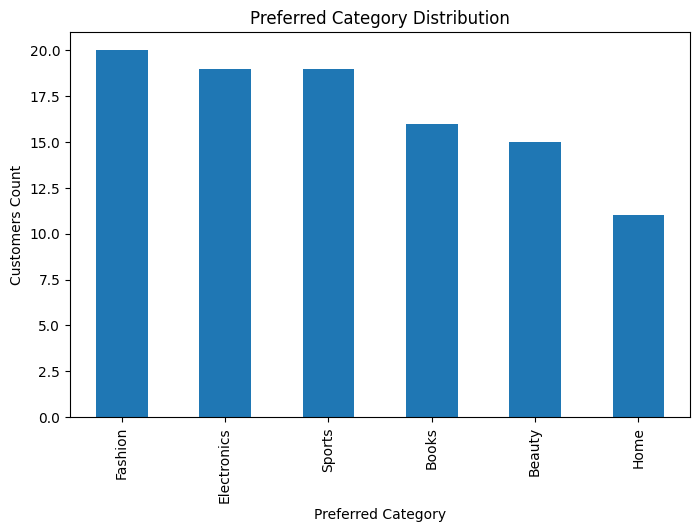

In [7]:
# Create a bar chart of Preferred_Category.
category_counts = df["Preferred_Category"].value_counts()

plt.figure(figsize=(8, 5))
category_counts.plot(kind="bar")

plt.title("Preferred Category Distribution")
plt.xlabel("Preferred Category")
plt.ylabel("Customers Count")

plt.show()

In [8]:
# Create a recommendation dictionary for each category.
recommendations = {
    "Electronics": [
        "Air Pods",
        "Apple Watch",
        "Bluetooth Speaker"
    ],
    "Fashion": [
        "Shirt",
        "Jeans",
        "Belt"
    ],
    "Books": [
        "Bible",
        "Python Programming",
        "Machine Learning"
    ],
    "Home": [
        "Coffee Maker",
        "Air Fryer",
        "Ironing Board"
    ],
    "Sports": [
        "Golf Clubs",
        "Baseball Glove",
        "Football"
    ],
    "Beauty": [
        "Lipstick",
        "Hair Brush",
        "Nail Polish"
    ]

}

print(recommendations)


{'Electronics': ['Air Pods', 'Apple Watch', 'Bluetooth Speaker'], 'Fashion': ['Shirt', 'Jeans', 'Belt'], 'Books': ['Bible', 'Python Programming', 'Machine Learning'], 'Home': ['Coffee Maker', 'Air Fryer', 'Ironing Board'], 'Sports': ['Golf Clubs', 'Baseball Glove', 'Football'], 'Beauty': ['Lipstick', 'Hair Brush', 'Nail Polish']}


In [9]:
# Add a new column named Recommendation.
df["Recommendation"] = df["Preferred_Category"].map(recommendations)

print(df)

    User_ID User_Name Preferred_Category  Pages_Visited  Time_Spent_Minutes  \
0         1     Priya        Electronics             12                   9   
1         2     Sneha            Fashion             12                   4   
2         3     Pooja              Books              1                   1   
3         4     Sneha            Fashion              9                  20   
4         5     Karan            Fashion             12                  21   
..      ...       ...                ...            ...                 ...   
95       96     Anita             Sports             14                   3   
96       97     Anita             Beauty              9                  13   
97       98     Rahul        Electronics             15                   9   
98       99     Pooja             Sports              1                   4   
99      100     Anita             Beauty             13                  11   

   Purchased                                 Recomm

In [10]:
# Save the updated dataset as recommendations.csv.
df.to_csv("recommendations.csv", index=False)

print("Dataset saved as recommendations.csv")

df.head(10)

Dataset saved as recommendations.csv


,User_ID,User_Name,Preferred_Category,Pages_Visited,Time_Spent_Minutes,Purchased,Recommendation
0,1,Priya,Electronics,12,9,Yes,"[Air Pods, Apple Watch, Bluetooth Speaker]"
1,2,Sneha,Fashion,12,4,Yes,"[Shirt, Jeans, Belt]"
2,3,Pooja,Books,1,1,Yes,"[Bible, Python Programming, Machine Learning]"
3,4,Sneha,Fashion,9,20,Yes,"[Shirt, Jeans, Belt]"
4,5,Karan,Fashion,12,21,No,"[Shirt, Jeans, Belt]"
5,6,Sneha,Books,10,9,Yes,"[Bible, Python Programming, Machine Learning]"
6,7,Amit,Beauty,7,11,No,"[Lipstick, Hair Brush, Nail Polish]"
7,8,Amit,Fashion,13,11,Yes,"[Shirt, Jeans, Belt]"
8,9,Priya,Books,2,12,No,"[Bible, Python Programming, Machine Learning]"
9,10,Pooja,Sports,13,2,No,"[Golf Clubs, Baseball Glove, Football]"
